In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

In [ ]:
import os

print(os.listdir('/content'))

['.config', 'occupancy+detection.zip', 'sample_data']


In [ ]:
import zipfile
import os

zip_path = "/content/occupancy+detection.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/occupancy_dataset")

print("Extraction completed!")
print(os.listdir("/content/occupancy_dataset"))

Extraction completed!
['datatest2.txt', 'datatest.txt', 'datatraining.txt']


In [ ]:
import pandas as pd
import os

data_path = "/content/occupancy_dataset"

# Load the three UCI files
train_df = pd.read_csv(os.path.join(data_path, "datatraining.txt"))
test_df = pd.read_csv(os.path.join(data_path, "datatest.txt"))
test2_df = pd.read_csv(os.path.join(data_path, "datatest2.txt"))

print("Training data shape:", train_df.shape)
print("Test data shape:", test_df.shape)
print("Test 2 data shape:", test2_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

Training data shape: (8143, 7)
Test data shape: (2665, 7)
Test 2 data shape: (9752, 7)

Columns:
['date', 'Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'Occupancy']


In [ ]:
# Select only the 4 features available from our live ThingSpeak source
features = [
    "Temperature",
    "Humidity",
    "CO2",
    "Light"
]

target = "Occupancy"

# Create clean datasets
train_clean = train_df[features + [target]].copy()
test_clean = test_df[features + [target]].copy()
test2_clean = test2_df[features + [target]].copy()

print("Training dataset:")
display(train_clean.head())

print("\nTraining shape:", train_clean.shape)
print("Test shape:", test_clean.shape)
print("Test 2 shape:", test2_clean.shape)

print("\nColumns:")
print(train_clean.columns.tolist())

Training dataset:


,Temperature,Humidity,CO2,Light,Occupancy
1,23.18,27.2720,721.25,426.0,1
2,23.15,27.2675,714.00,429.5,1
3,23.15,27.2450,713.50,426.0,1
4,23.15,27.2000,708.25,426.0,1
5,23.10,27.2000,704.50,426.0,1



Training shape: (8143, 5)
Test shape: (2665, 5)
Test 2 shape: (9752, 5)

Columns:
['Temperature', 'Humidity', 'CO2', 'Light', 'Occupancy']


In [ ]:
print("Missing values:")
print(train_clean.isnull().sum())

print("\nData types:")
print(train_clean.dtypes)

print("\nDescriptive statistics:")
display(train_clean.describe())

Missing values:
Temperature    0
Humidity       0
CO2            0
Light          0
Occupancy      0
dtype: int64

Data types:
Temperature    float64
Humidity       float64
CO2            float64
Light          float64
Occupancy        int64
dtype: object

Descriptive statistics:


,Temperature,Humidity,CO2,Light,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,606.546243,119.519375,0.212330
std,1.016916,5.531211,314.320877,194.755805,0.408982
min,19.000000,16.745000,412.750000,0.000000,0.000000
25%,19.700000,20.200000,439.000000,0.000000,0.000000
50%,20.390000,26.222500,453.500000,0.000000,0.000000
75%,21.390000,30.533333,638.833333,256.375000,0.000000
max,23.180000,39.117500,2028.500000,1546.333333,1.000000


In [ ]:
print("Occupancy distribution:")
print(train_clean["Occupancy"].value_counts())

print("\nOccupancy percentages:")
print(train_clean["Occupancy"].value_counts(normalize=True) * 100)

Occupancy distribution:
Occupancy
0    6414
1    1729
Name: count, dtype: int64

Occupancy percentages:
Occupancy
0    78.767039
1    21.232961
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the training dataset for EDA
df = train_clean.copy()

# Make sure Occupancy is numeric
df["Occupancy"] = pd.to_numeric(df["Occupancy"])

# Feature list
features = ["Temperature", "Humidity", "CO2", "Light"]

# Set plotting style
sns.set_theme(style="whitegrid")

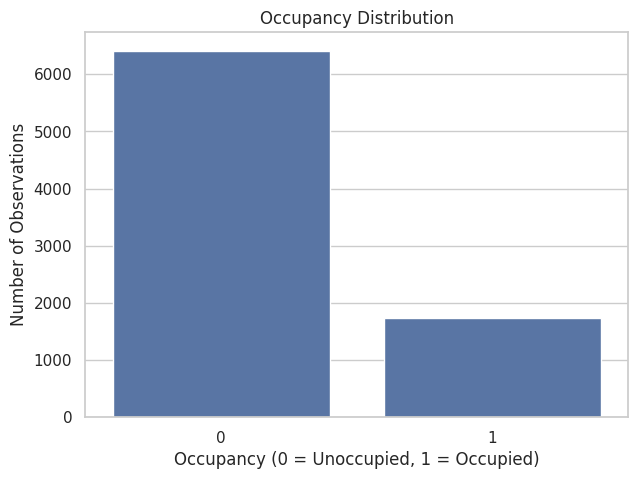

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Occupancy"
)

plt.title("Occupancy Distribution")
plt.xlabel("Occupancy (0 = Unoccupied, 1 = Occupied)")
plt.ylabel("Number of Observations")

plt.show()

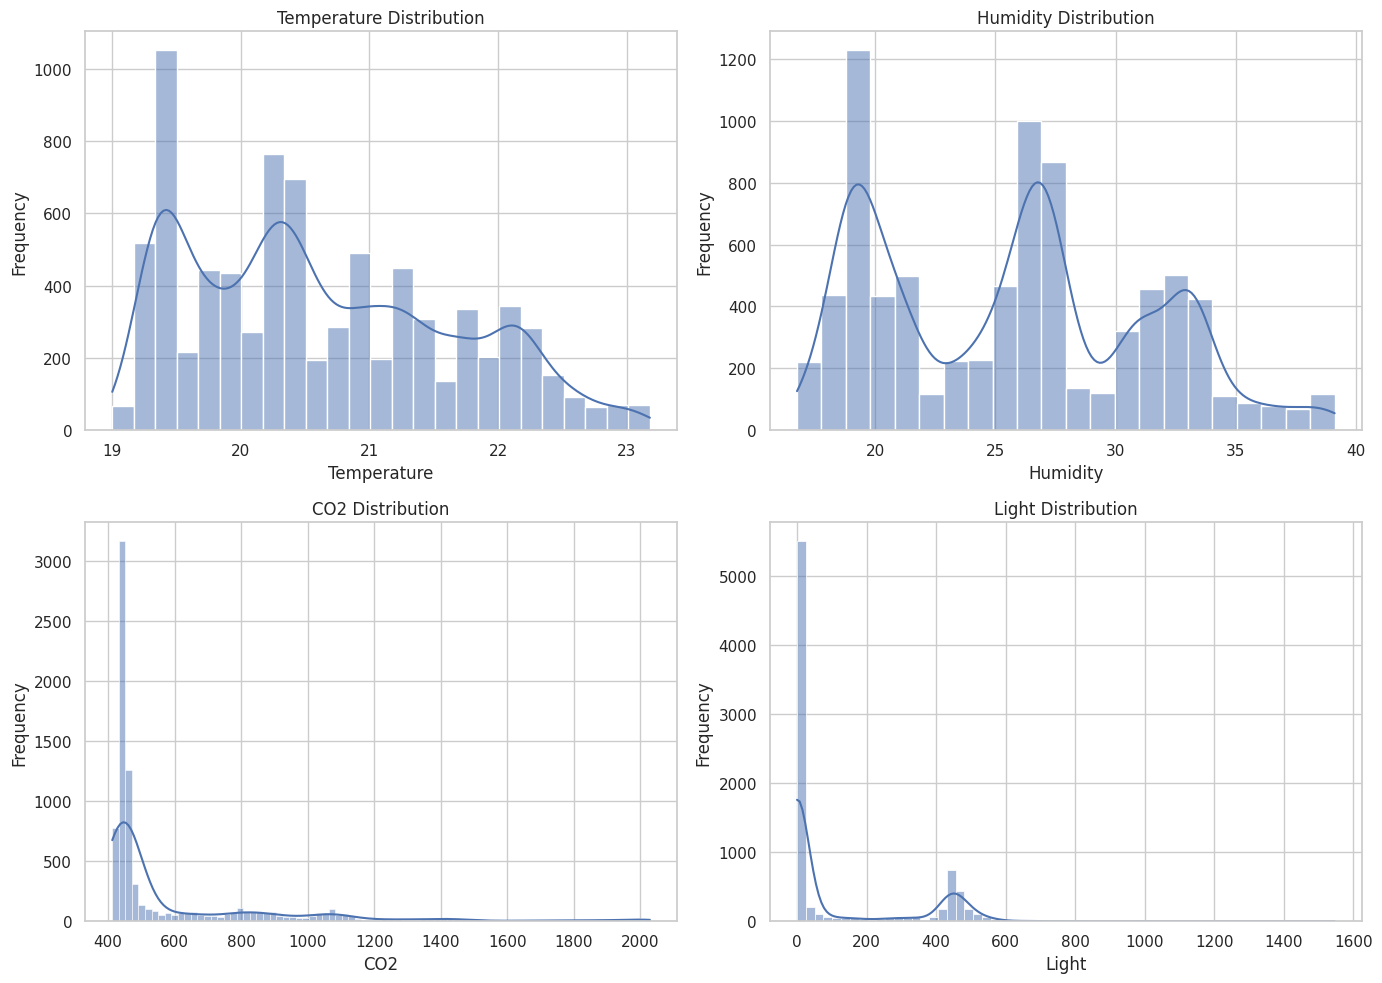

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.ravel(), features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

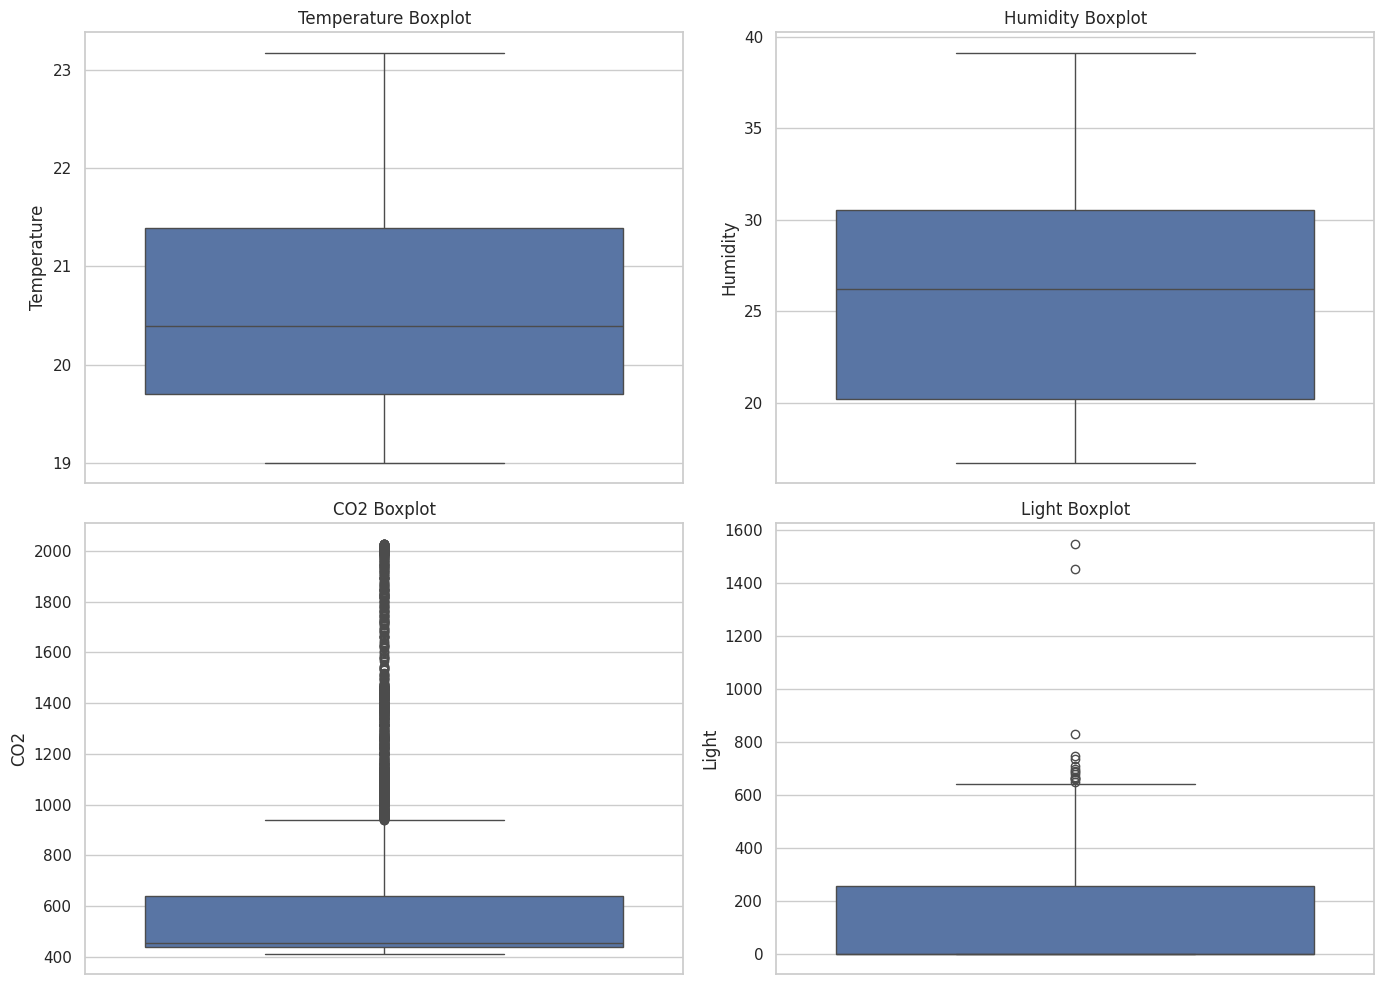

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(
        data=df,
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} Boxplot")

plt.tight_layout()
plt.show()

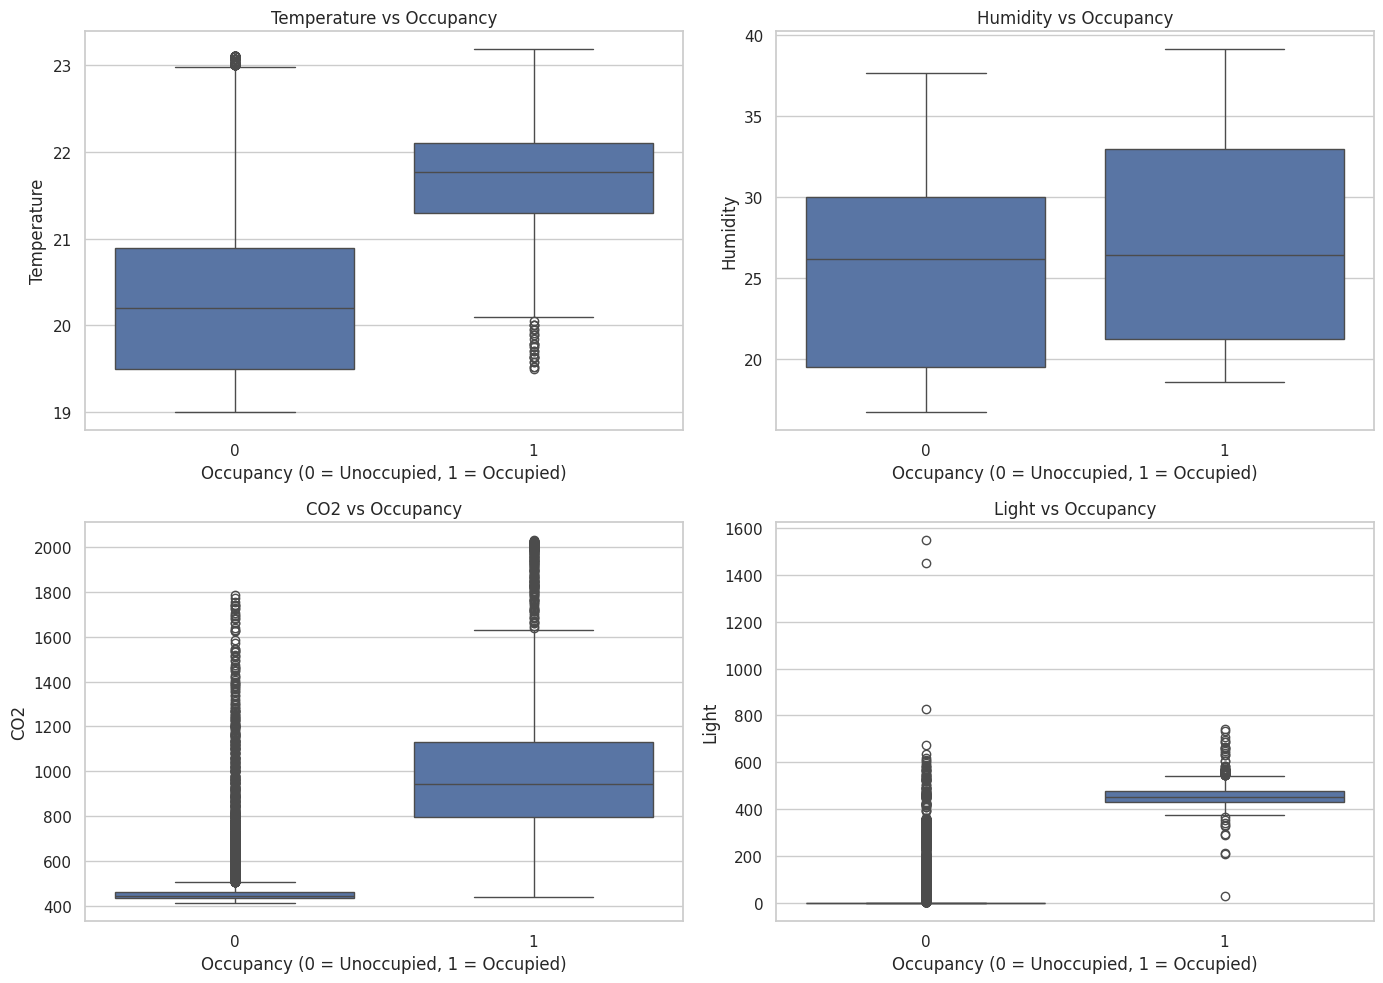

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.ravel(), features):
    sns.boxplot(
        data=df,
        x="Occupancy",
        y=feature,
        ax=ax
    )

    ax.set_title(f"{feature} vs Occupancy")
    ax.set_xlabel("Occupancy (0 = Unoccupied, 1 = Occupied)")

plt.tight_layout()
plt.show()

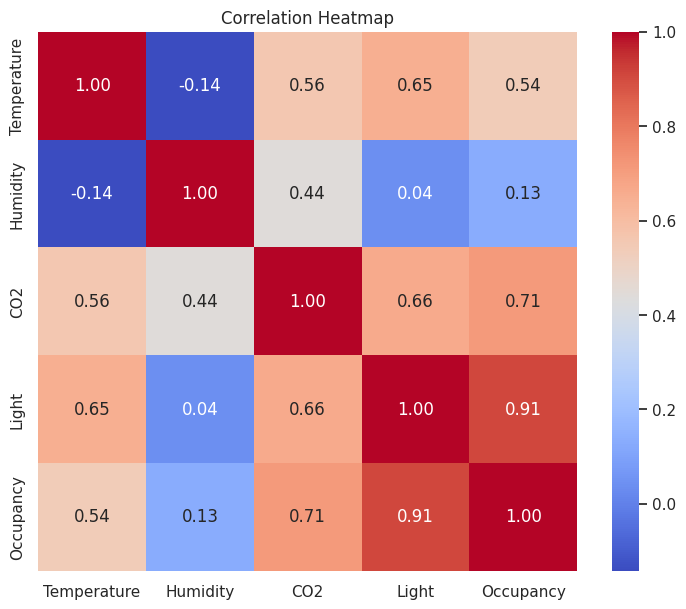

In [ ]:
plt.figure(figsize=(9, 7))

correlation = df[features + ["Occupancy"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# ==========================================
# STEP 10: PREPARE DATA FOR MACHINE LEARNING
# ==========================================

from sklearn.preprocessing import StandardScaler

# Input features
X_train = train_clean[features]
y_train = train_clean[target]

X_test = test_clean[features]
y_test = test_clean[target]

X_test2 = test2_clean[features]
y_test2 = test2_clean[target]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("X_test2 shape:", X_test2.shape)
print("y_test2 shape:", y_test2.shape)

X_train shape: (8143, 4)
y_train shape: (8143,)
X_test shape: (2665, 4)
y_test shape: (2665,)
X_test2 shape: (9752, 4)
y_test2 shape: (9752,)


In [ ]:
# ==========================================
# STEP 11: FEATURE STANDARDIZATION
# ==========================================

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)
X_test2_scaled = scaler.transform(X_test2)

print("Standardization completed!")

print("\nFirst 5 standardized training rows:")
print(X_train_scaled[:5])

Standardization completed!

First 5 standardized training rows:
[[2.51847007 0.27852622 0.36494808 1.57376283]
 [2.48896731 0.27771261 0.34188106 1.59173515]
 [2.48896731 0.27364453 0.34029023 1.57376283]
 [2.48896731 0.26550838 0.32358653 1.57376283]
 [2.43979604 0.26550838 0.31165532 1.57376283]]


In [ ]:
# Check means and standard deviations after scaling

print("Training feature means after scaling:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations after scaling:")
print(X_train_scaled.std(axis=0))

Training feature means after scaling:
[ 7.81832606e-16  4.46761489e-16 -1.88477503e-16  2.23380745e-16]

Training feature standard deviations after scaling:
[1. 1. 1. 1.]


In [ ]:
# ==========================================
# STEP 13: LOGISTIC REGRESSION
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Create model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train
logistic_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = logistic_model.predict(X_test_scaled)

# Prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_auc:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy : 0.9779
Precision: 0.9471
Recall   : 0.9949
F1-Score : 0.9704
ROC-AUC  : 0.9916


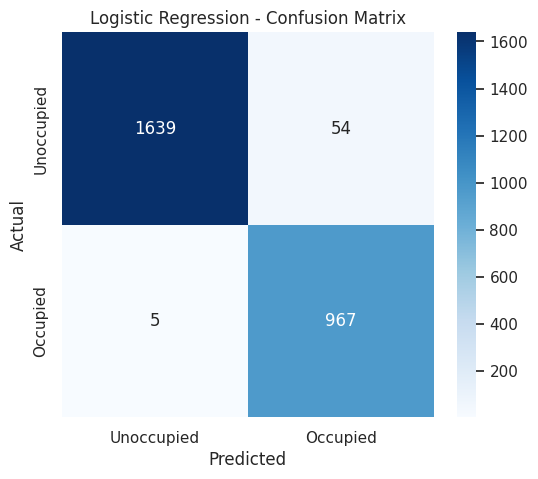

In [ ]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unoccupied", "Occupied"],
    yticklabels=["Unoccupied", "Occupied"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================
# STEP 14: KNN CLASSIFICATION
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Test different K values
k_values = range(1, 21)

cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_scores.append(scores.mean())

# Find the best K
best_k = k_values[cv_scores.index(max(cv_scores))]

print("Best K:", best_k)
print("Best Cross-Validation Accuracy:", max(cv_scores))

Best K: 20
Best Cross-Validation Accuracy: 0.9349177153044556


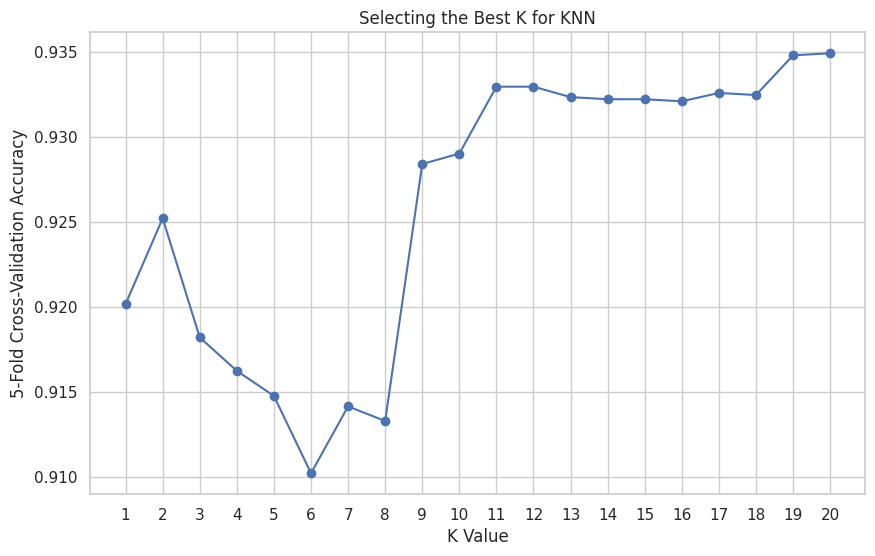

In [ ]:
# ==========================================
# K VALUE vs CROSS-VALIDATION ACCURACY
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    cv_scores,
    marker="o"
)

plt.xlabel("K Value")
plt.ylabel("5-Fold Cross-Validation Accuracy")
plt.title("Selecting the Best K for KNN")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [ ]:
# ==========================================
# TRAIN FINAL KNN MODEL
# ==========================================

knn_model = KNeighborsClassifier(
    n_neighbors=best_k
)

knn_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_scaled)

# Probabilities
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_auc = roc_auc_score(y_test, y_prob_knn)

print("KNN RESULTS")
print("=" * 35)
print(f"Best K   : {best_k}")
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")
print(f"ROC-AUC  : {knn_auc:.4f}")

KNN RESULTS
Best K   : 20
Accuracy : 0.9328
Precision: 0.9670
Recall   : 0.8447
F1-Score : 0.9017
ROC-AUC  : 0.9896


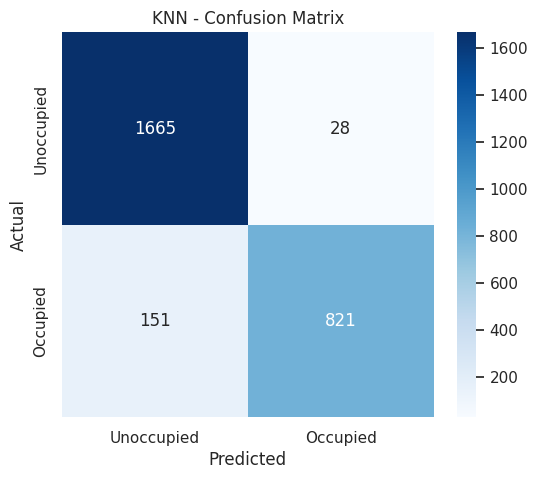

In [ ]:
# ==========================================
# KNN CONFUSION MATRIX
# ==========================================

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unoccupied", "Occupied"],
    yticklabels=["Unoccupied", "Occupied"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# STEP 15 - DECISION TREE
# Hyperparameter Tuning using GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_model = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_dt = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid_dt,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)

print("Best Decision Tree Parameters:")
print(grid_dt.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_dt.best_score_)

Best Decision Tree Parameters:
{'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross-Validation Accuracy:
0.9726206367090345


In [ ]:
# Train the best Decision Tree model

best_dt_model = grid_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test_scaled)
y_prob_dt = best_dt_model.predict_proba(X_test_scaled)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results")
print("-" * 35)
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1-Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

Decision Tree Results
-----------------------------------
Accuracy : 0.9782363977485928
Precision: 0.9480392156862745
Recall   : 0.9948559670781894
F1-Score : 0.9708835341365462
ROC-AUC  : 0.9822216388469588


In [ ]:
# Decision Tree Classification Report

print("Decision Tree Classification Report")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Unoccupied", "Occupied"]
    )
)

Decision Tree Classification Report
----------------------------------------
              precision    recall  f1-score   support

  Unoccupied       1.00      0.97      0.98      1693
    Occupied       0.95      0.99      0.97       972

    accuracy                           0.98      2665
   macro avg       0.97      0.98      0.98      2665
weighted avg       0.98      0.98      0.98      2665



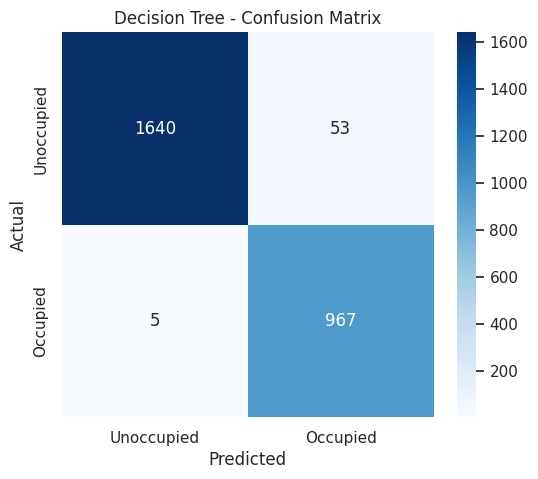

In [ ]:
# DECISION TREE CONFUSION MATRIX

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unoccupied", "Occupied"],
    yticklabels=["Unoccupied", "Occupied"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# DECISION TREE FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_dt_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
3        Light    0.986764
2          CO2    0.007261
0  Temperature    0.005975
1     Humidity    0.000000


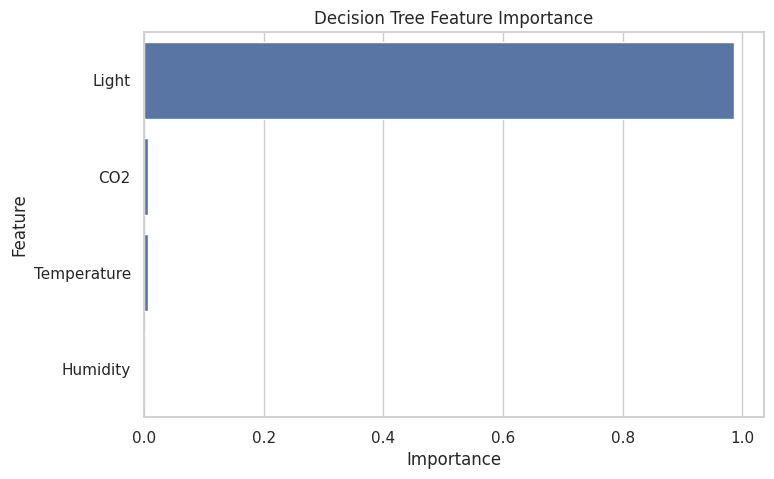

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [ ]:
# ==========================================
# STEP 16: SVM CLASSIFICATION
# Hyperparameter Tuning using GridSearchCV
# ==========================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_model = SVC(
    probability=True,
    random_state=42
)

param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"]
}

grid_svm = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

print("Best SVM Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid_svm.best_score_)

Best SVM Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Best Cross-Validation Accuracy:
0.9733518551198109


In [ ]:
# ==========================================
# TRAIN BEST SVM MODEL
# ==========================================

best_svm_model = grid_svm.best_estimator_

y_pred_svm = best_svm_model.predict(X_test_scaled)
y_prob_svm = best_svm_model.predict_proba(X_test_scaled)[:, 1]

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_prob_svm)

print("SVM Results")
print("-" * 35)
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1-Score :", svm_f1)
print("ROC-AUC  :", svm_auc)

SVM Results
-----------------------------------
Accuracy : 0.9786116322701689
Precision: 0.9472140762463344
Recall   : 0.9969135802469136
F1-Score : 0.9714285714285714
ROC-AUC  : 0.9910020442441522


In [ ]:
# ==========================================
# SVM CLASSIFICATION REPORT
# ==========================================

print("SVM Classification Report")
print("-" * 35)

print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=["Unoccupied", "Occupied"]
    )
)

SVM Classification Report
-----------------------------------
              precision    recall  f1-score   support

  Unoccupied       1.00      0.97      0.98      1693
    Occupied       0.95      1.00      0.97       972

    accuracy                           0.98      2665
   macro avg       0.97      0.98      0.98      2665
weighted avg       0.98      0.98      0.98      2665



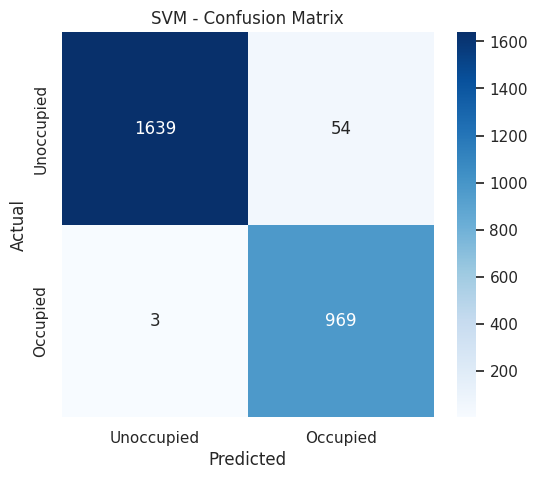

In [ ]:
# ==========================================
# SVM CONFUSION MATRIX
# ==========================================

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unoccupied", "Occupied"],
    yticklabels=["Unoccupied", "Occupied"]
)

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================
# STEP 17: MODEL COMPARISON
# Compare all trained models
# ==========================================

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        svm_accuracy
    ],
    "Precision": [
        lr_precision,
        knn_precision,
        dt_precision,
        svm_precision
    ],
    "Recall": [
        lr_recall,
        knn_recall,
        dt_recall,
        svm_recall
    ],
    "F1-Score": [
        lr_f1,
        knn_f1,
        dt_f1,
        svm_f1
    ],
    "ROC-AUC": [
        lr_auc,
        knn_auc,
        dt_auc,
        svm_auc
    ]
})

print("Model Comparison")
print("=" * 80)

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Model Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9779,0.9471,0.9949,0.9704,0.9916
1,KNN,0.9328,0.9670,0.8447,0.9017,0.9896
2,Decision Tree,0.9782,0.9480,0.9949,0.9709,0.9822
3,SVM,0.9786,0.9472,0.9969,0.9714,0.9910


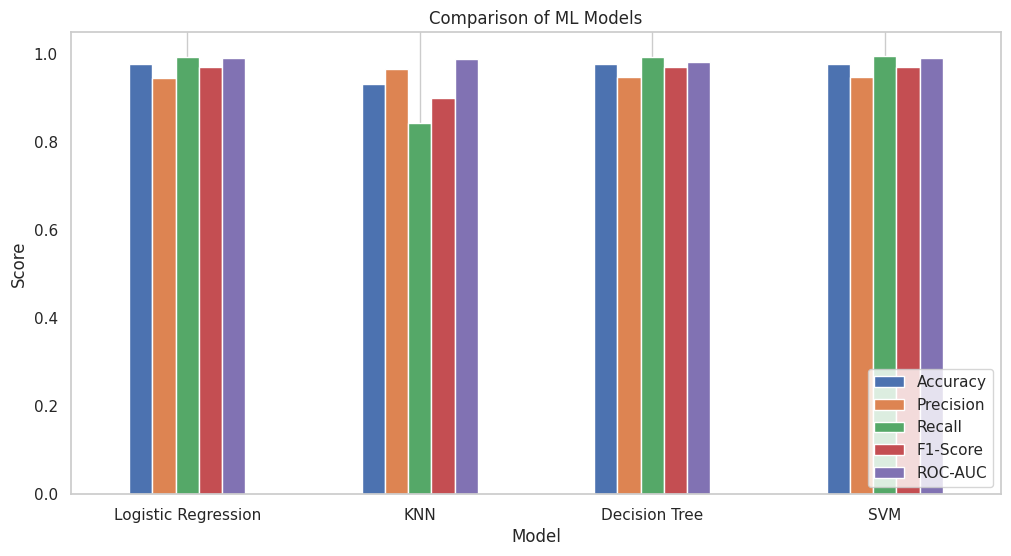

In [ ]:
# ==========================================
# MODEL COMPARISON GRAPH
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_plot = model_comparison.set_index("Model")[metrics]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of ML Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.show()

In [ ]:
# ==========================================
# MODEL SELECTION
# ==========================================

best_model_name = model_comparison.loc[
    model_comparison["F1-Score"].idxmax(),
    "Model"
]

print("Model with highest F1-Score:", best_model_name)

Model with highest F1-Score: SVM


In [ ]:
# ==========================================
# STEP 18: VOTING ENSEMBLE
# Combine Logistic Regression, KNN,
# Decision Tree and SVM
# ==========================================

from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("lr", logistic_model),
        ("knn", knn_model),
        ("dt", best_dt_model),
        ("svm", best_svm_model)
    ],
    voting="soft"
)

voting_model.fit(X_train_scaled, y_train)

y_pred_voting = voting_model.predict(X_test_scaled)
y_prob_voting = voting_model.predict_proba(X_test_scaled)[:, 1]

print("Voting Ensemble trained successfully!")

Voting Ensemble trained successfully!


In [ ]:
# ==========================================
# VOTING ENSEMBLE EVALUATION
# ==========================================

voting_accuracy = accuracy_score(y_test, y_pred_voting)
voting_precision = precision_score(y_test, y_pred_voting)
voting_recall = recall_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting)
voting_auc = roc_auc_score(y_test, y_prob_voting)

print("Voting Ensemble Results")
print("-" * 40)
print("Accuracy :", voting_accuracy)
print("Precision:", voting_precision)
print("Recall   :", voting_recall)
print("F1-Score :", voting_f1)
print("ROC-AUC  :", voting_auc)

Voting Ensemble Results
----------------------------------------
Accuracy : 0.9786116322701689
Precision: 0.9472140762463344
Recall   : 0.9969135802469136
F1-Score : 0.9714285714285714
ROC-AUC  : 0.990327516595811


In [ ]:
# ==========================================
# VOTING ENSEMBLE CLASSIFICATION REPORT
# ==========================================

print("Voting Ensemble Classification Report")
print("-" * 45)

print(
    classification_report(
        y_test,
        y_pred_voting,
        target_names=["Unoccupied", "Occupied"]
    )
)

Voting Ensemble Classification Report
---------------------------------------------
              precision    recall  f1-score   support

  Unoccupied       1.00      0.97      0.98      1693
    Occupied       0.95      1.00      0.97       972

    accuracy                           0.98      2665
   macro avg       0.97      0.98      0.98      2665
weighted avg       0.98      0.98      0.98      2665



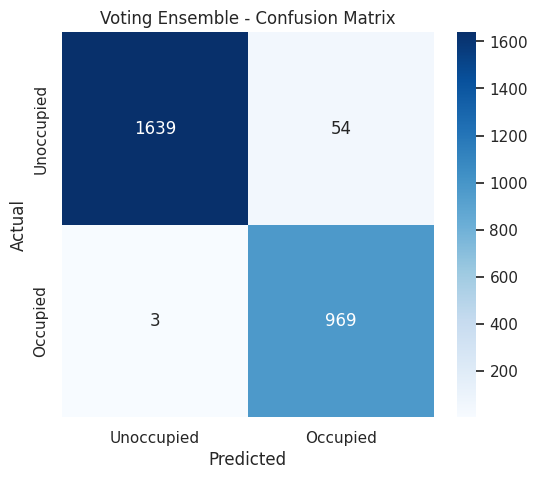

In [ ]:
# ==========================================
# VOTING ENSEMBLE CONFUSION MATRIX
# ==========================================

cm_voting = confusion_matrix(y_test, y_pred_voting)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_voting,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Unoccupied", "Occupied"],
    yticklabels=["Unoccupied", "Occupied"]
)

plt.title("Voting Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================
# UPDATE MODEL COMPARISON WITH ENSEMBLE
# ==========================================

model_comparison_final = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM",
        "Voting Ensemble"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        svm_accuracy,
        voting_accuracy
    ],
    "Precision": [
        lr_precision,
        knn_precision,
        dt_precision,
        svm_precision,
        voting_precision
    ],
    "Recall": [
        lr_recall,
        knn_recall,
        dt_recall,
        svm_recall,
        voting_recall
    ],
    "F1-Score": [
        lr_f1,
        knn_f1,
        dt_f1,
        svm_f1,
        voting_f1
    ],
    "ROC-AUC": [
        lr_auc,
        knn_auc,
        dt_auc,
        svm_auc,
        voting_auc
    ]
})

display(
    model_comparison_final.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9779,0.9471,0.9949,0.9704,0.9916
1,KNN,0.9328,0.9670,0.8447,0.9017,0.9896
2,Decision Tree,0.9782,0.9480,0.9949,0.9709,0.9822
3,SVM,0.9786,0.9472,0.9969,0.9714,0.9910
4,Voting Ensemble,0.9786,0.9472,0.9969,0.9714,0.9903


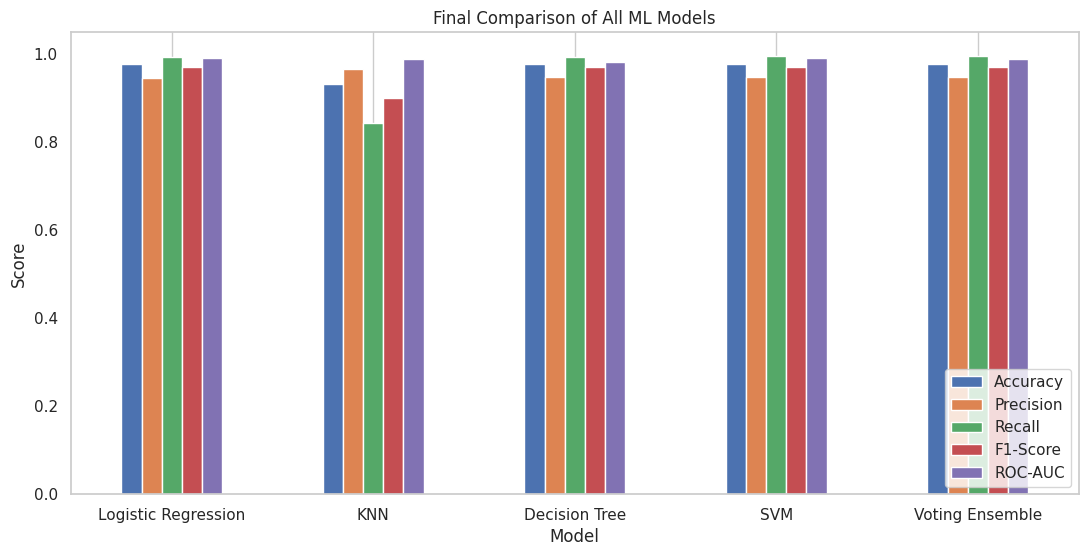

In [ ]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

model_comparison_final.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title("Final Comparison of All ML Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")

plt.show()

In [ ]:
# ==========================================
# STEP 19: LIVE THINGSPEAK DATA
# ==========================================

import requests
import pandas as pd

THINGSPEAK_URL = "https://api.thingspeak.com/channels/3285964/feeds.json?results=1"

response = requests.get(THINGSPEAK_URL, timeout=10)
response.raise_for_status()

data = response.json()

# Get latest feed
feed = data["feeds"][0]

# Convert live values to numeric
live_temperature = float(feed["field1"])
live_humidity = float(feed["field2"])
live_co2 = float(feed["field3"])
live_light = float(feed["field5"])

print("Latest ThingSpeak Sensor Data")
print("=" * 40)
print(f"Temperature : {live_temperature:.2f} °C")
print(f"Humidity    : {live_humidity:.2f} %")
print(f"CO2         : {live_co2:.2f} ppm")
print(f"Light       : {live_light:.2f} lux")
print(f"Timestamp   : {feed['created_at']}")

Latest ThingSpeak Sensor Data
Temperature : 31.10 °C
Humidity    : 68.81 %
CO2         : 728.00 ppm
Light       : 113.00 lux
Timestamp   : 2026-09-20T09:00:46Z


In [ ]:
# ==========================================
# PREPARE LIVE DATA FOR ML PREDICTION
# ==========================================

live_data = pd.DataFrame([{
    "Temperature": live_temperature,
    "Humidity": live_humidity,
    "CO2": live_co2,
    "Light": live_light
}])

print("Live Input:")
display(live_data)

# Apply the SAME scaler used during training
live_data_scaled = scaler.transform(live_data)

print("Scaled Live Input:")
print(live_data_scaled)

Live Input:


,Temperature,Humidity,CO2,Light
0,31.1,68.81,728.0,113.0


Scaled Live Input:
[[10.30719885  7.78873525  0.38642427 -0.03347667]]


In [ ]:
# ==========================================
# LIVE OCCUPANCY PREDICTION
# ==========================================

live_prediction = voting_model.predict(live_data_scaled)[0]
live_probability = voting_model.predict_proba(live_data_scaled)[0]

if live_prediction == 1:
    occupancy_status = "Occupied"
else:
    occupancy_status = "Unoccupied"

confidence = live_probability[live_prediction]

print("LIVE OCCUPANCY PREDICTION")
print("=" * 40)
print("Occupancy Status:", occupancy_status)
print(f"Confidence      : {confidence:.4f}")
print(f"Confidence (%)  : {confidence * 100:.2f}%")

LIVE OCCUPANCY PREDICTION
Occupancy Status: Unoccupied
Confidence      : 0.8249
Confidence (%)  : 82.49%


In [ ]:
# ==========================================
# ENERGY RECOMMENDATION
# ==========================================

if live_prediction == 1:
    recommendation = "Normal operation recommended."
else:
    recommendation = "Energy-saving mode recommended."

print("ENERGY RECOMMENDATION")
print("=" * 40)
print(recommendation)

ENERGY RECOMMENDATION
Energy-saving mode recommended.


In [ ]:
# ==========================================
# STEP 20: LIVE SMART ROOM SUMMARY
# ==========================================

print("=" * 60)
print("        SMART ROOM AI - LIVE STATUS")
print("=" * 60)

print("\nLIVE SENSOR DATA")
print("-" * 60)
print(f"Temperature : {live_temperature:.2f} °C")
print(f"Humidity    : {live_humidity:.2f} %")
print(f"CO2         : {live_co2:.2f} ppm")
print(f"Light       : {live_light:.2f} lux")

print("\nAI PREDICTION")
print("-" * 60)
print(f"Occupancy   : {occupancy_status}")
print(f"Confidence  : {confidence * 100:.2f}%")

print("\nENERGY RECOMMENDATION")
print("-" * 60)
print(recommendation)

print("\nThingSpeak Timestamp:")
print(feed["created_at"])

print("=" * 60)

        SMART ROOM AI - LIVE STATUS

LIVE SENSOR DATA
------------------------------------------------------------
Temperature : 31.10 °C
Humidity    : 68.81 %
CO2         : 728.00 ppm
Light       : 113.00 lux

AI PREDICTION
------------------------------------------------------------
Occupancy   : Unoccupied
Confidence  : 82.49%

ENERGY RECOMMENDATION
------------------------------------------------------------
Energy-saving mode recommended.

ThingSpeak Timestamp:
2026-09-20T09:00:46Z


In [ ]:
# ==========================================
# LIVE PREDICTION HISTORY
# ==========================================

from datetime import datetime

live_record = pd.DataFrame([{
    "Timestamp": feed["created_at"],
    "Temperature": live_temperature,
    "Humidity": live_humidity,
    "CO2": live_co2,
    "Light": live_light,
    "Occupancy": occupancy_status,
    "Confidence": confidence,
    "Recommendation": recommendation
}])

display(live_record)

,Timestamp,Temperature,Humidity,CO2,Light,Occupancy,Confidence,Recommendation
0,2026-09-20T09:00:46Z,31.1,68.81,728.0,113.0,Unoccupied,0.824919,Energy-saving mode recommended.


In [ ]:
# ==========================================
# SAVE LIVE READING
# ==========================================

history_file = "smartroom_live_history.csv"

if os.path.exists(history_file):
    history_df = pd.read_csv(history_file)
    history_df = pd.concat(
        [history_df, live_record],
        ignore_index=True
    )
else:
    history_df = live_record.copy()

history_df.to_csv(history_file, index=False)

print("Live reading saved successfully.")
print("Total records:", len(history_df))

Live reading saved successfully.
Total records: 1


In [ ]:
# ==========================================
# STEP 21: LIVE HISTORY ANALYTICS
# ==========================================

history_df = pd.read_csv("smartroom_live_history.csv")

history_df["Timestamp"] = pd.to_datetime(history_df["Timestamp"])

print("Live Prediction History")
print("=" * 50)

display(history_df)

Live Prediction History


,Timestamp,Temperature,Humidity,CO2,Light,Occupancy,Confidence,Recommendation
0,2026-09-20 09:00:46+00:00,31.1,68.81,728.0,113.0,Unoccupied,0.824919,Energy-saving mode recommended.


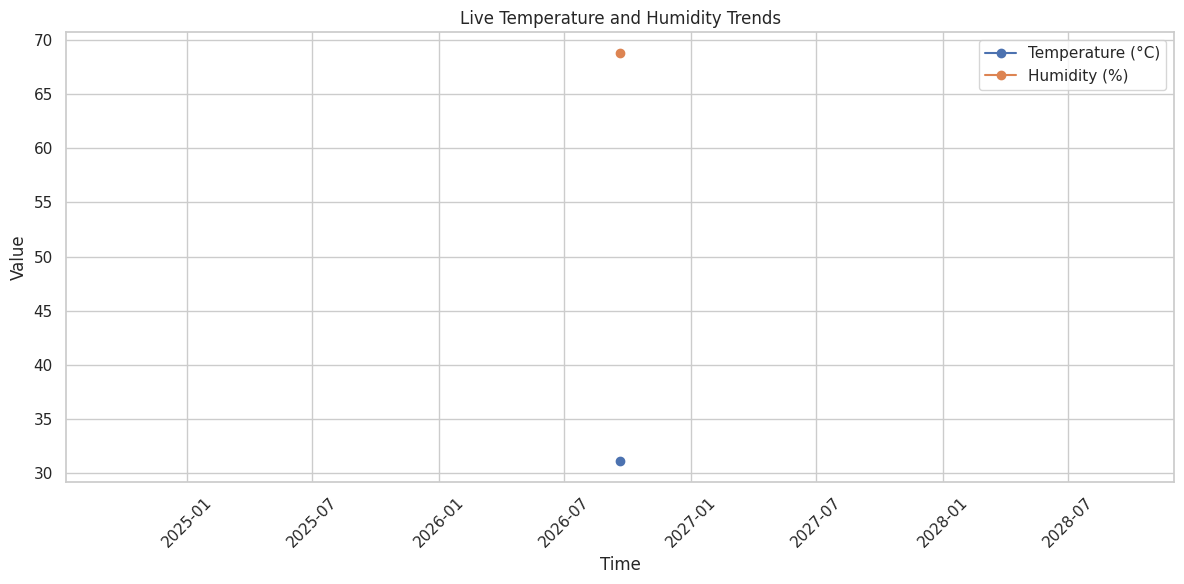

In [ ]:
# ==========================================
# SENSOR TREND GRAPH
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    history_df["Timestamp"],
    history_df["Temperature"],
    marker="o",
    label="Temperature (°C)"
)

plt.plot(
    history_df["Timestamp"],
    history_df["Humidity"],
    marker="o",
    label="Humidity (%)"
)

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Live Temperature and Humidity Trends")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

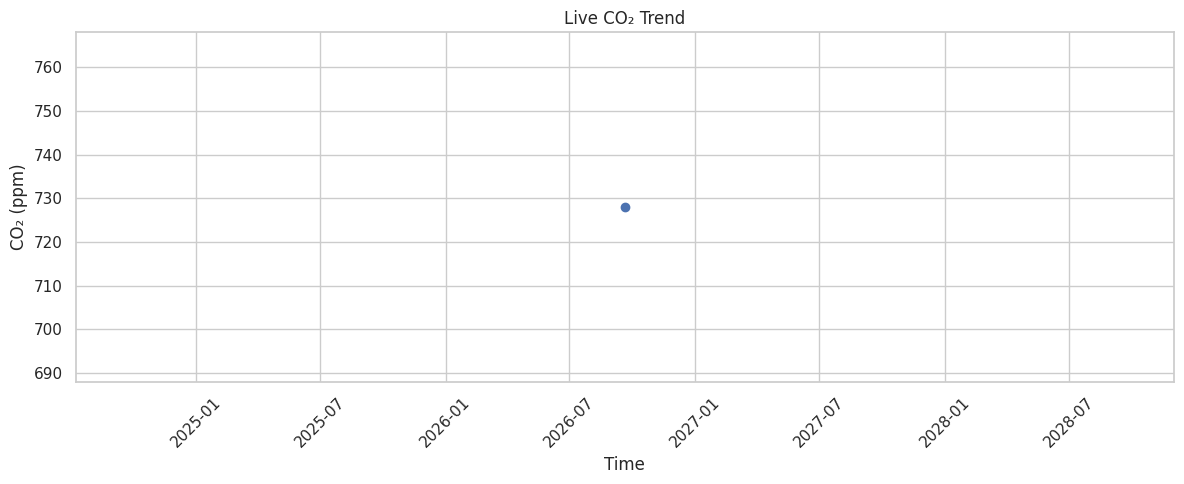

In [ ]:
# ==========================================
# CO2 TREND
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    history_df["Timestamp"],
    history_df["CO2"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("CO₂ (ppm)")
plt.title("Live CO₂ Trend")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

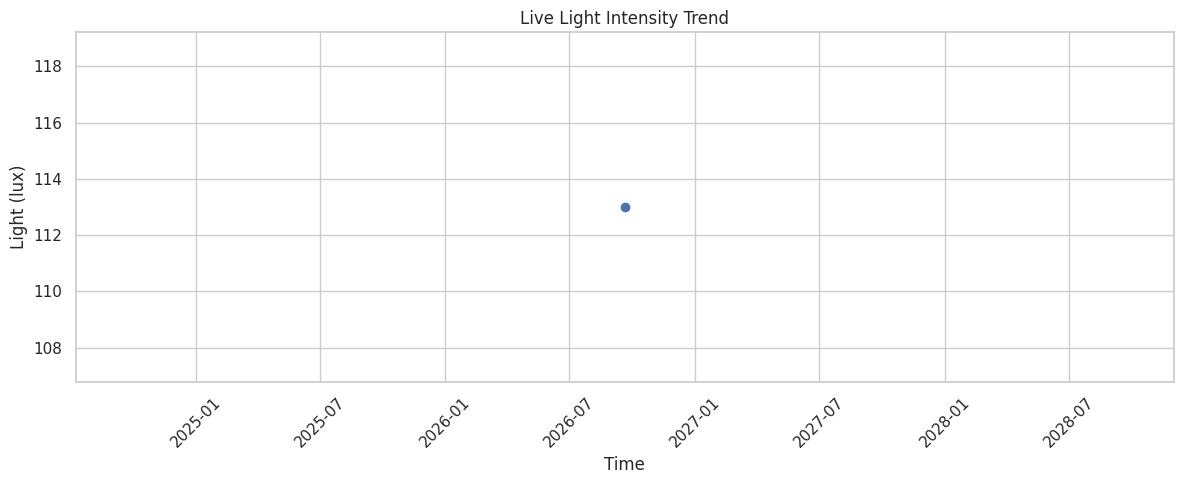

In [ ]:
# ==========================================
# LIGHT TREND
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    history_df["Timestamp"],
    history_df["Light"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Light (lux)")
plt.title("Live Light Intensity Trend")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

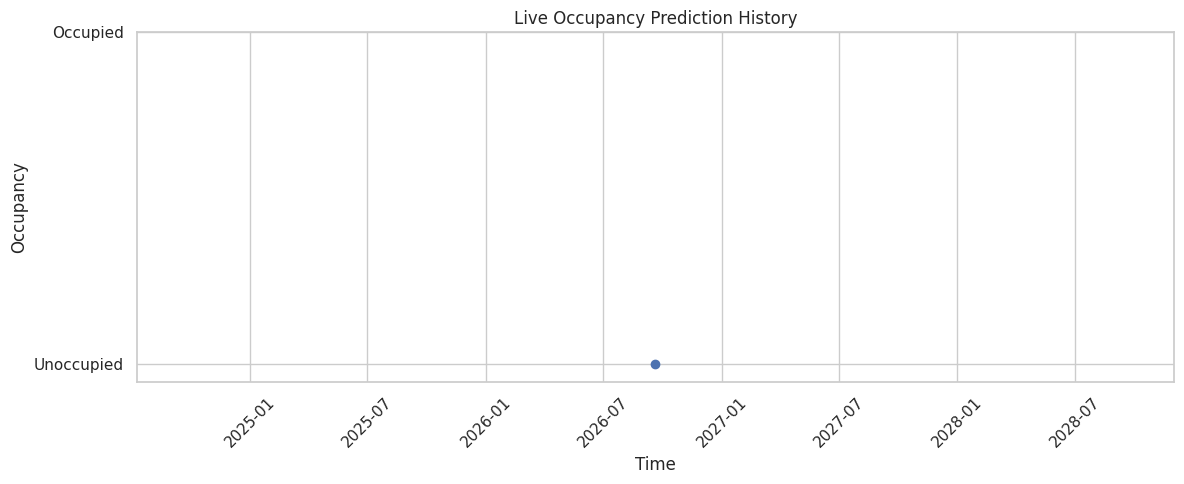

In [ ]:
# ==========================================
# OCCUPANCY HISTORY
# ==========================================

occupancy_numeric = history_df["Occupancy"].map({
    "Unoccupied": 0,
    "Occupied": 1
})

plt.figure(figsize=(12, 5))

plt.step(
    history_df["Timestamp"],
    occupancy_numeric,
    where="post",
    marker="o"
)

plt.yticks(
    [0, 1],
    ["Unoccupied", "Occupied"]
)

plt.xlabel("Time")
plt.ylabel("Occupancy")
plt.title("Live Occupancy Prediction History")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

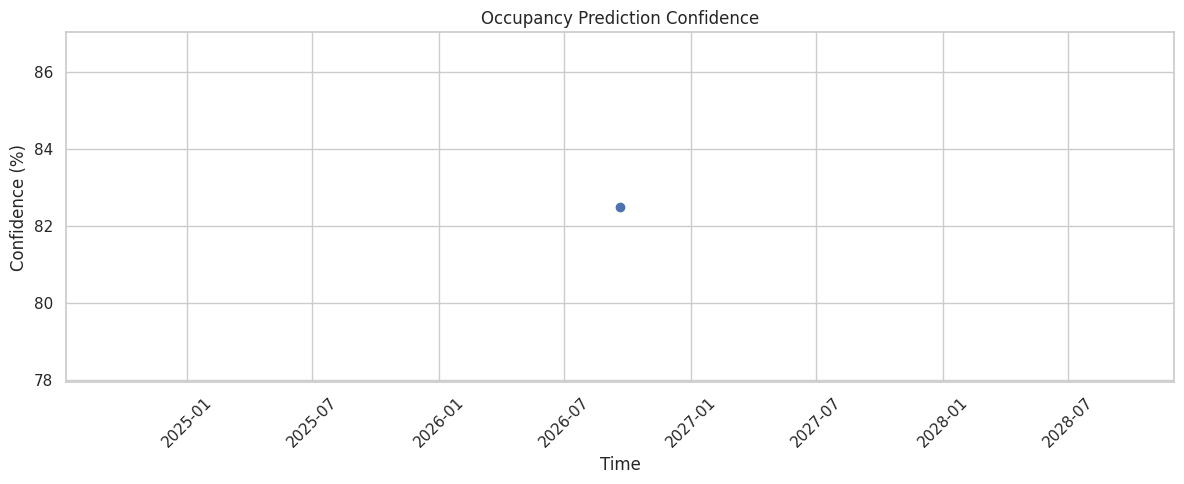

In [ ]:
# ==========================================
# CONFIDENCE TREND
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    history_df["Timestamp"],
    history_df["Confidence"] * 100,
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Confidence (%)")
plt.title("Occupancy Prediction Confidence")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# STEP 22: SAVE TRAINED ML MODEL
# ==========================================

import joblib
import os

# Create model directory
os.makedirs("saved_model", exist_ok=True)

# Save Voting Ensemble
joblib.dump(
    voting_model,
    "saved_model/smartroom_voting_model.pkl"
)

# Save the scaler used during training
joblib.dump(
    scaler,
    "saved_model/smartroom_scaler.pkl"
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [ ]:
# ==========================================
# SAVE FEATURE INFORMATION
# ==========================================

feature_info = {
    "features": features,
    "target": target
}

joblib.dump(
    feature_info,
    "saved_model/feature_info.pkl"
)

print("Feature information saved successfully.")
print("Features:", features)
print("Target:", target)

Feature information saved successfully.
Features: ['Temperature', 'Humidity', 'CO2', 'Light']
Target: Occupancy


In [ ]:
# ==========================================
# SAVE MODEL COMPARISON RESULTS
# ==========================================

model_comparison_final.to_csv(
    "saved_model/model_comparison.csv",
    index=False
)

print("Model comparison results saved successfully.")
display(model_comparison_final)

Model comparison results saved successfully.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.977861,0.947111,0.994856,0.970396,0.991615
1,KNN,0.932833,0.967020,0.844650,0.901702,0.989561
2,Decision Tree,0.978236,0.948039,0.994856,0.970884,0.982222
3,SVM,0.978612,0.947214,0.996914,0.971429,0.991002
4,Voting Ensemble,0.978612,0.947214,0.996914,0.971429,0.990328


In [ ]:
# ==========================================
# VERIFY SAVED MODEL FILES
# ==========================================

print("Saved Model Files:")
print("=" * 40)

for file in os.listdir("saved_model"):
    print(file)

Saved Model Files:
smartroom_scaler.pkl
feature_info.pkl
smartroom_voting_model.pkl
model_comparison.csv


In [ ]:
# ==========================================
# TEST MODEL LOADING
# ==========================================

loaded_model = joblib.load(
    "saved_model/smartroom_voting_model.pkl"
)

loaded_scaler = joblib.load(
    "saved_model/smartroom_scaler.pkl"
)

print("Saved model loaded successfully.")
print("Saved scaler loaded successfully.")

Saved model loaded successfully.
Saved scaler loaded successfully.


In [ ]:
# ==========================================
# TEST LOADED MODEL WITH LIVE DATA
# ==========================================

loaded_live_scaled = loaded_scaler.transform(live_data)

loaded_prediction = loaded_model.predict(
    loaded_live_scaled
)[0]

loaded_probability = loaded_model.predict_proba(
    loaded_live_scaled
)[0]

if loaded_prediction == 1:
    loaded_status = "Occupied"
else:
    loaded_status = "Unoccupied"

loaded_confidence = loaded_probability[loaded_prediction]

print("Loaded Model Prediction")
print("=" * 40)
print("Occupancy :", loaded_status)
print(f"Confidence: {loaded_confidence * 100:.2f}%")

Loaded Model Prediction
Occupancy : Unoccupied
Confidence: 82.49%


In [ ]:
# ==========================================
# CREATE ML DEPLOYMENT PACKAGE
# ==========================================

import shutil
import os

# Check saved model files
print("Files to be packaged:")
print("=" * 40)

for file in os.listdir("saved_model"):
    print(file)

# Create ZIP package
shutil.make_archive(
    "SmartRoom_ML_Deployment",
    "zip",
    "saved_model"
)

print("\nML deployment package created successfully!")
print("SmartRoom_ML_Deployment.zip")

Files to be packaged:
smartroom_scaler.pkl
feature_info.pkl
smartroom_voting_model.pkl
model_comparison.csv

ML deployment package created successfully!
SmartRoom_ML_Deployment.zip


In [ ]:
from google.colab import files

files.download("SmartRoom_ML_Deployment.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>